In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr

# Single gene-trait association plots

In [2]:
## Single gene-trait association plot
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'
# gene_name = 'APOB'

In [3]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)

exp_annos = pl.DataFrame({
    "category": ["protein_abundance", "protein_abundance"],
    "annotation": ["olink_score", "olink_score_abs"],
    "color": ["gray", "gray"],
    "label": ["Plasma Olink", "Plasma Olink (abs)"],
    "annotation_dir": [-1, 1],
})

anno_config_df = pl.concat([anno_config_df, exp_annos], how='vertical')
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory_nondir""","""abexp_min""","""#00A99D""","""AbExp min""",-1
"""regulatory""","""promoterai""","""#00A99D""","""PromoterAI""",1


In [10]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928_olink_vsm.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
variant_class = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -0
max_range = +100

anno = (
    anno
    .filter(
        filter_expression &

        # (pl.col('consequence_splice_acceptor_variant') == 0) & (pl.col('consequence_splice_donor_variant') == 0) &
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)

        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Filter to gene
        (pl.col('gene_name') == gene_name) &
        
        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

am_pathogenicity,delta_score,TSS,absplice2_max,absplice_dna_max,esmscoremissense,promoterai_abs,cadd_raw,olink_score_abs,gene_name,region,mamphylop,gene_length,verphylop,gpn_score,pangolin_score,loftee_hc,Strand,dist_to_tss,abexp_min,promoterai,id,gpn_star_llr_calibrated_mean,olink_score
f32,f32,i64,f32,f32,f32,f32,f32,f32,str,str,f32,i64,f32,f32,f32,i8,cat,i64,f64,f32,str,f64,f32
0.1173,0.0,11089461,0.000321,0.003,-3.488,0.0,1.500346,0.592591,"""LDLR""","""ENSG00000130164""",0.525,44360,1.026,-4.89,0.0,0,"""+""",38607,-0.05204,0.0,"""chr19:11128068:C:T""",-4.17865,-0.592591
0.0782,0.0,11089461,0.000428,0.003,-4.708,0.0,0.658688,0.417848,"""LDLR""","""ENSG00000130164""",-0.298,44360,-0.129,-0.37,0.0,0,"""+""",17179,-0.005303,0.0,"""chr19:11106640:G:A""",-1.58834,-0.417848
0.3591,0.0,11089461,0.000432,0.005,-8.959,0.0,4.063156,0.448867,"""LDLR""","""ENSG00000130164""",2.747,44360,1.39,-7.93,0.0,0,"""+""",27509,-0.066728,0.0,"""chr19:11116970:C:A""",-6.907135,-0.448867
0.0739,0.0,11089461,0.000341,0.003,-3.82,0.0,1.531969,0.442957,"""LDLR""","""ENSG00000130164""",1.853,44360,1.3,-3.34,0.0,0,"""+""",40168,-0.04167,0.0,"""chr19:11129629:G:A""",-2.514278,0.442957
0.143,0.0,11089461,0.002321,0.003,-4.963,0.0,2.791123,0.693563,"""LDLR""","""ENSG00000130164""",4.367,44360,2.113,-5.77,0.05,0,"""+""",41828,-0.229451,0.0,"""chr19:11131289:G:T""",-6.117341,-0.693563
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.1615,0.0,11089461,0.000321,0.003,-5.908,0.0,2.607435,null,"""LDLR""","""ENSG00000130164""",1.805,44360,4.705,-6.62,0.0,0,"""+""",23864,-0.074067,0.0,"""chr19:11113325:A:T""",-5.966514,null
0.2338,0.0,11089461,0.000321,0.003,-7.13,0.0,3.159204,null,"""LDLR""","""ENSG00000130164""",2.766,44360,3.704,-4.74,0.0,0,"""+""",33875,-0.112486,0.0,"""chr19:11123336:C:T""",-2.303069,null
0.1701,0.01,11089461,0.002247,0.003,-10.191,0.0,4.416002,null,"""LDLR""","""ENSG00000130164""",3.369,44360,8.414,-6.94,0.01,0,"""+""",21197,-0.069889,0.0,"""chr19:11110658:A:G""",-5.758696,null


In [11]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11128068:C:T""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11106640:G:A""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11116970:C:A""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11129629:G:A""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11131289:G:T""","""ENSG00000130164""","""loftee_hc""",0.0
…,…,…,…
"""chr19:11113325:A:T""","""ENSG00000130164""","""olink_score_abs""",null
"""chr19:11123336:C:T""","""ENSG00000130164""","""olink_score_abs""",null
"""chr19:11110658:A:G""","""ENSG00000130164""","""olink_score_abs""",null


In [12]:
# Get phenotype data for the phenotype of interest
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet").filter(pl.col('phenotype') == phenotype).collect(engine='streaming')

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno, 
        on="id", 
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']), 
        on=['id', 'region'], 
        how='inner'
    )
)

pg_df

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,mean_pheno_value_rank,mean_pheno_value_ptile,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u32,f32,f32,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr19:11128068:C:T""","""ldl_direct_int""",2,0.204275,1.667551,3.667046e7,0.673797,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",38607
"""chr19:11106640:G:A""","""ldl_direct_int""",6,-0.039559,0.911931,2.4318484e7,0.446837,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",17179
"""chr19:11116970:C:A""","""ldl_direct_int""",36,0.254643,1.166427,3.8303828e7,0.703809,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",27509
"""chr19:11129629:G:A""","""ldl_direct_int""",5,-0.070178,0.888724,2.2797e7,0.418881,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",40168
"""chr19:11131289:G:T""","""ldl_direct_int""",17,0.017257,0.922801,2.8515786e7,0.52396,"""ENSG00000130164""","""loftee_hc""",0.0,11089461,"""+""",44360,"""LDLR""",41828
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11105481:G:C""","""ldl_direct_int""",1,-0.579045,null,8.676137e6,0.159419,"""ENSG00000130164""","""olink_score_abs""",null,11089461,"""+""",44360,"""LDLR""",16020
"""chr19:11105433:G:T""","""ldl_direct_int""",1,-0.054143,null,2.3573496e7,0.433148,"""ENSG00000130164""","""olink_score_abs""",null,11089461,"""+""",44360,"""LDLR""",15972
"""chr19:11113325:A:T""","""ldl_direct_int""",17,0.848232,0.671946,4.9221964e7,0.904423,"""ENSG00000130164""","""olink_score_abs""",null,11089461,"""+""",44360,"""LDLR""",23864


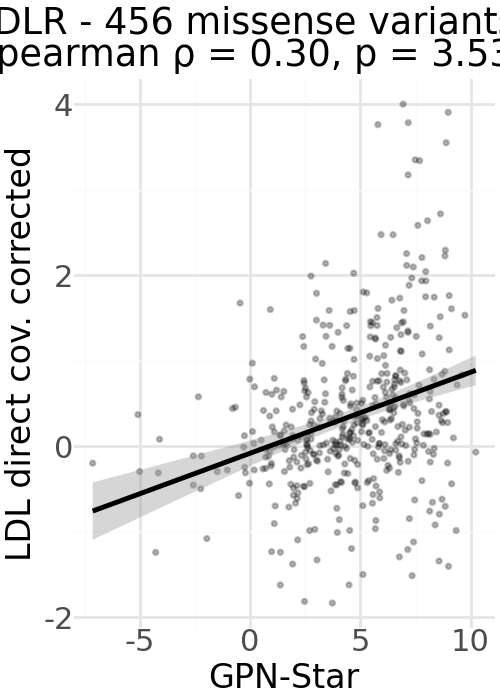

In [23]:
annotation = 'gpn_star_llr_calibrated_mean'
# annotation = 'am_pathogenicity'
# annotation = 'cadd_raw'
# annotation = 'olink_score'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
    .drop_nulls(subset=['annotation_score', 'mean_pheno_value'])
    .with_columns(
        annotation_score = -pl.col('annotation_score'),
    )
)

spearman_corr, p_value = spearmanr(
        plot_df['annotation_score'],
        plot_df['mean_pheno_value']
    )

(
    # ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25, size=0.5, color='black') +
    stat_smooth(method='glm', se=True) +
    # scale_color_gradient(low='steelblue', high='darkred') +
    # scale_color_gradient(low='black', high='black') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y="LDL direct cov. corrected",
        title=f"{gene_name} - {plot_df.shape[0]} {variant_class} variants\nSpearman ρ = {spearman_corr:.2f}, p = {p_value:.2e}"
    ) +
    theme(
        figure_size=(2.5, 3.5),
        legend_position='none',
        # axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=11),
        axis_title=element_text(size=12),
    )
)

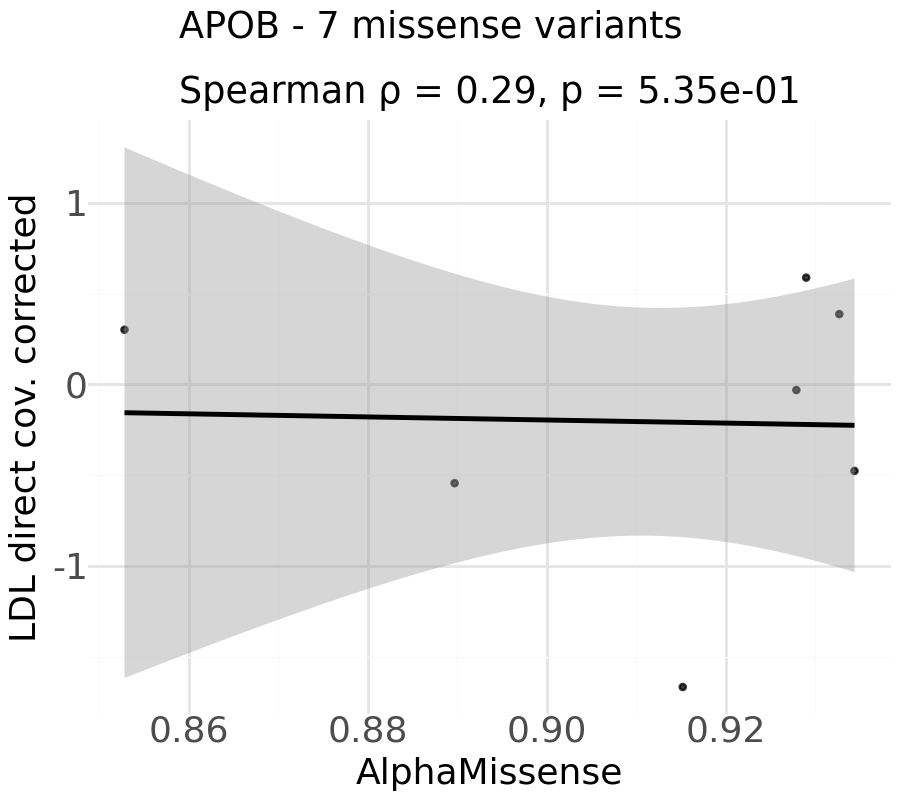

In [21]:
hi_df = (
    plot_df
    # C. Compute rank and percentile in a single, combined step
    .with_columns(
        # Use *[...] to create and unpack a list of expressions
        *[
            expression
            for c in ['annotation_score', 'mean_pheno_value']
            
            for expression in [
                # Expression 1: Rank
                pl.col(c).rank("average").over(["region", "phenotype", "annotation"]).alias(f"{c}_rank"),
                
                # Expression 2: Percentile
                (pl.col(c).rank("average").over(["region", "phenotype", "annotation"]) / pl.col(c).count().over(["region", "phenotype", "annotation"])).alias(f"{c}_percentile")
            ]
        ]
    )
)

plot_hi = hi_df.filter(
    # (pl.col('annotation_score_percentile')<0.01) |
    (pl.col('annotation_score_percentile')>0.99)
)

spearman_corr, p_value = spearmanr(
        plot_hi['annotation_score'],
        plot_hi['mean_pheno_value']
    )

# (
#     ggplot(plot_hi, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
#     geom_point(alpha=0.25) +
#     stat_smooth(method='lm', se=True) +
#     scale_color_gradient(low='steelblue', high='darkred') +
#     theme_minimal() +
#     labs(
#         x=f"{anno_label}",
#         y="LDL direct cov. corrected",
#         title=f"{gene_name} - {plot_hi.shape[0]} {variant_class} variants\nSpearman ρ = {spearman_corr:.2f}, p = {p_value:.2e}"
#     ) +
#     theme(
#         figure_size=(4.5, 4),
#         legend_position='none'
#     )
# )

(
    # ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    ggplot(plot_hi, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.75, size=0.75, color='black') +
    stat_smooth(method='glm', se=True) +
    # scale_color_gradient(low='steelblue', high='darkred') +
    # scale_color_gradient(low='black', high='black') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y="LDL direct cov. corrected",
        title=f"{gene_name} - {plot_hi.shape[0]} {variant_class} variants\n\nSpearman ρ = {spearman_corr:.2f}, p = {p_value:.2e}"
    ) +
    theme(
        figure_size=(4.5, 4),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
    )
)

## Other annotations

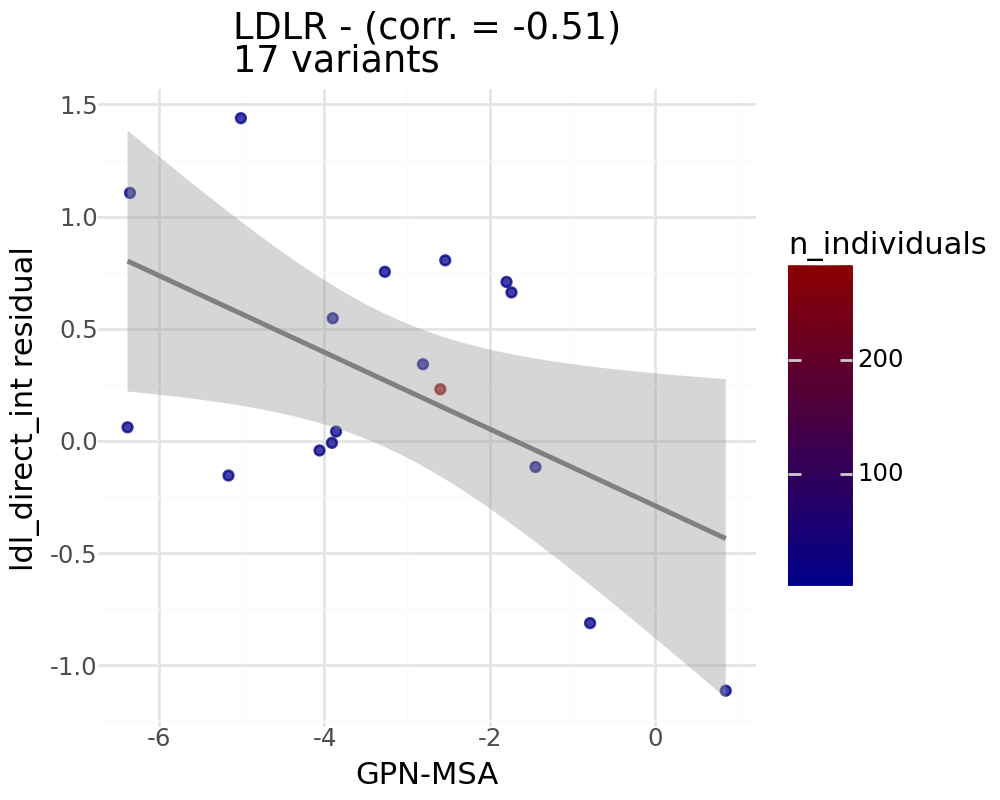

In [43]:
annotation = 'gpn_score'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

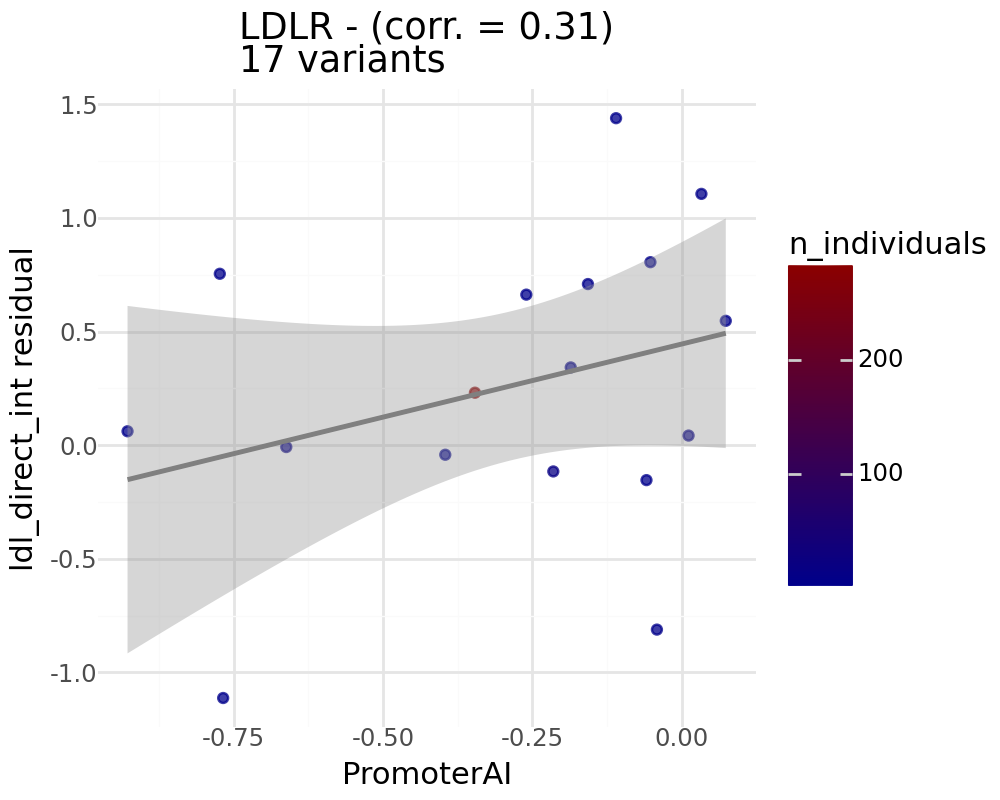

In [44]:
annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

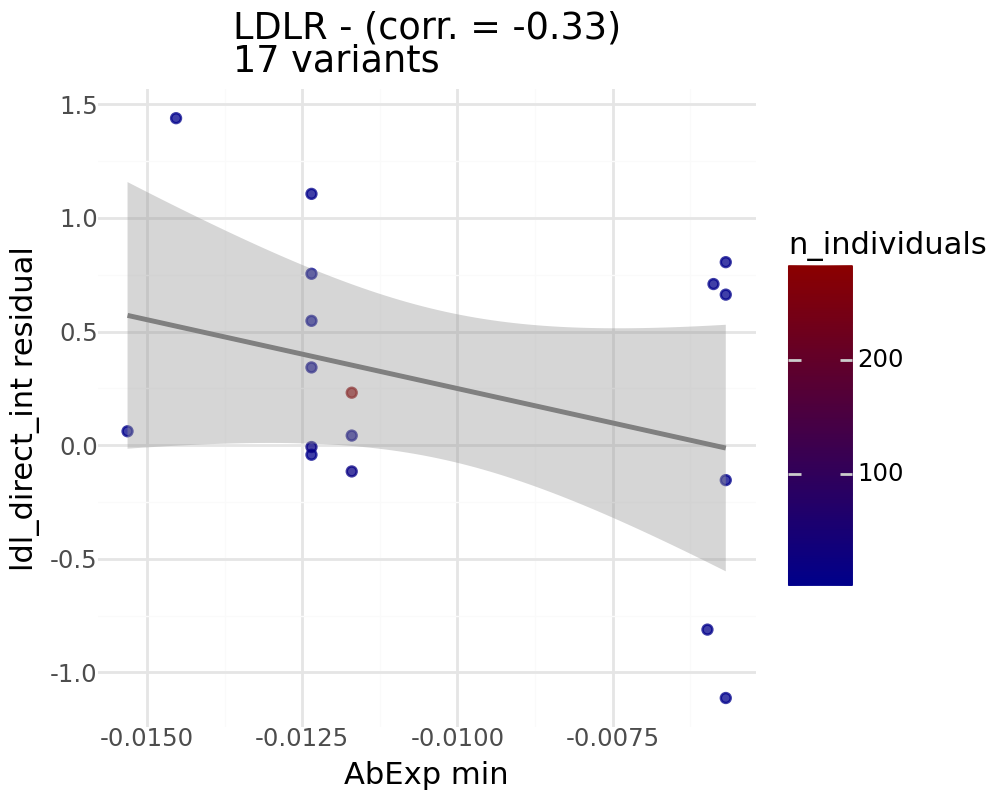

In [45]:
annotation = 'abexp_min'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

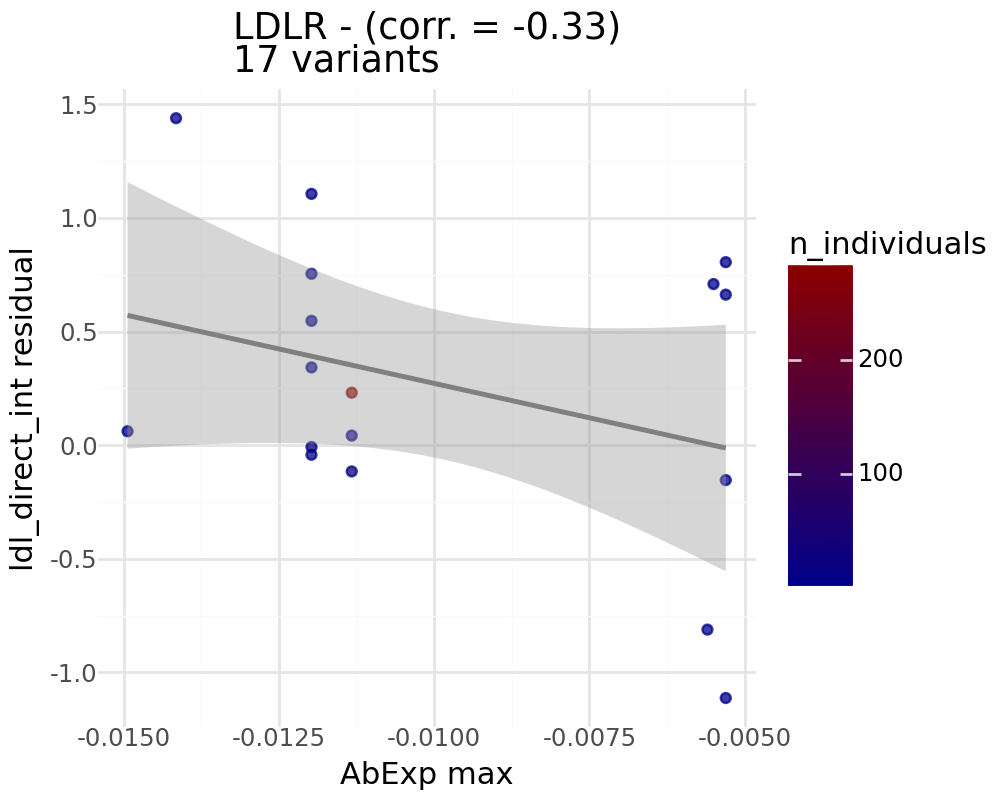

In [46]:
annotation = 'abexp_max'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('dist_to_tss') >= -50) &
        (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.75) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='darkblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)